In [1]:
import os
import torch
import torch.nn.functional as F
import torchvision.models as models
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using: {device}")

Using: cuda


In [3]:
from google.colab import drive
drive.mount('/content/drive')

PASSION_ROOT = "/content/drive/MyDrive/PASSION_MICCAI_2024"
IMG_DIR      = os.path.join(PASSION_ROOT, "images")
CSV_PATH     = os.path.join(PASSION_ROOT, "label.csv")

df = pd.read_csv(CSV_PATH)
print(f"Metadata rows: {len(df)}")
print(df['conditions_PASSION'].value_counts())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Metadata rows: 1653
conditions_PASSION
Fungal     579
Scabies    471
Eczema     414
Others     189
Name: count, dtype: int64


In [4]:
PASSION_CLASSES = {
    'Fungal':  0,
    'Scabies': 1,
    'Eczema':  2,
    'Others':  3,
}

CLASS_NAMES = ['Fungal', 'Scabies', 'Eczema', 'Others']

class PASSIONDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.img_dir   = img_dir
        self.transform = transform
        self.samples   = []

        subject_lookup = {
            row['subject_id']: {
                'label':       PASSION_CLASSES[row['conditions_PASSION']],
                'fitzpatrick': row['fitzpatrick']
            }
            for _, row in df.iterrows()
        }

        for filename in os.listdir(img_dir):
            if not filename.endswith(('.jpg', '.jpeg', '.png')):
                continue
            if '(' in filename:
                continue

            subject_id = filename.rsplit('_', 1)[0]

            if subject_id not in subject_lookup:
                continue

            info = subject_lookup[subject_id]
            self.samples.append((
                os.path.join(img_dir, filename),
                info['label'],
                info['fitzpatrick']
            ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label, fitzpatrick = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label, fitzpatrick

In [5]:
# Use the exact transforms MobileNetV3 was trained with
weights  = models.MobileNet_V3_Small_Weights.DEFAULT
transform = weights.transforms()

dataset = PASSIONDataset(df, IMG_DIR, transform=transform)
loader  = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Total images: {len(dataset)}")
print(f"Total batches: {len(loader)}")

Total images: 4901
Total batches: 154


In [6]:
model_b1 = models.mobilenet_v3_small(weights=weights).to(device)
model_b1.eval()
print("B1 loaded — MobileNetV3-Small (ImageNet, 1000 classes)")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 132MB/s]


B1 loaded — MobileNetV3-Small (ImageNet, 1000 classes)


In [7]:
def evaluate_b1(model, loader, device):
    """
    E1 evaluation for an ImageNet model on PASSION.

    Since B1 outputs 1000 ImageNet classes (not our 4 PASSION classes),
    we cannot measure accuracy. Instead we measure:
      - Average max confidence per Fitzpatrick type
      - This shows whether the model is MORE uncertain on dark skin tones
    """
    model.eval()

    # Track confidence per fitzpatrick type
    fitz_confidences = defaultdict(list)
    all_confidences  = []

    with torch.no_grad():
        for batch_idx, (images, labels, fitzpatricks) in enumerate(loader):
            images = images.to(device)

            outputs     = model(images)
            probs       = F.softmax(outputs, dim=1)
            confidences, _ = torch.max(probs, dim=1)

            # Store per fitzpatrick type
            for conf, fitz in zip(confidences.cpu(), fitzpatricks):
                fitz_confidences[fitz.item()].append(conf.item())
                all_confidences.append(conf.item())

            if batch_idx % 10 == 0:
                print(f"  Batch {batch_idx}/{len(loader)} done...")

    # Compute average confidence per fitzpatrick type
    avg_conf_per_fitz = {
        fitz: sum(confs) / len(confs)
        for fitz, confs in sorted(fitz_confidences.items())
    }

    overall_avg_conf = sum(all_confidences) / len(all_confidences)

    return overall_avg_conf, avg_conf_per_fitz


def print_e1_results(model_name, overall_conf, fitz_confs):
    print(f"\n{'='*50}")
    print(f"  {model_name} — E1 Results")
    print(f"{'='*50}")
    print(f"  Overall avg confidence:  {overall_conf:.4f}")
    print(f"\n  Confidence by Fitzpatrick type:")
    for fitz, conf in fitz_confs.items():
        bar = "█" * int(conf * 30)
        print(f"    Type {fitz}: {conf:.4f}  {bar}")
    print(f"{'='*50}\n")

In [8]:
print("Running E1 — evaluating B1 (ImageNet MobileNetV3) on PASSION...")

overall_conf_b1, fitz_confs_b1 = evaluate_b1(model_b1, loader, device)
print_e1_results("MobileNetV3-Small (ImageNet)", overall_conf_b1, fitz_confs_b1)

Running E1 — evaluating B1 (ImageNet MobileNetV3) on PASSION...
  Batch 0/154 done...


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95136000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (97389000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


  Batch 10/154 done...
  Batch 20/154 done...


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (95094000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


  Batch 30/154 done...
  Batch 40/154 done...
  Batch 50/154 done...


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (94716000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


  Batch 60/154 done...
  Batch 70/154 done...
  Batch 80/154 done...
  Batch 90/154 done...
  Batch 100/154 done...
  Batch 110/154 done...
  Batch 120/154 done...
  Batch 130/154 done...
  Batch 140/154 done...
  Batch 150/154 done...

  MobileNetV3-Small (ImageNet) — E1 Results
  Overall avg confidence:  0.3169

  Confidence by Fitzpatrick type:
    Type 1: 0.3216  █████████
    Type 3: 0.3133  █████████
    Type 4: 0.3277  █████████
    Type 5: 0.3247  █████████
    Type 6: 0.2730  ████████



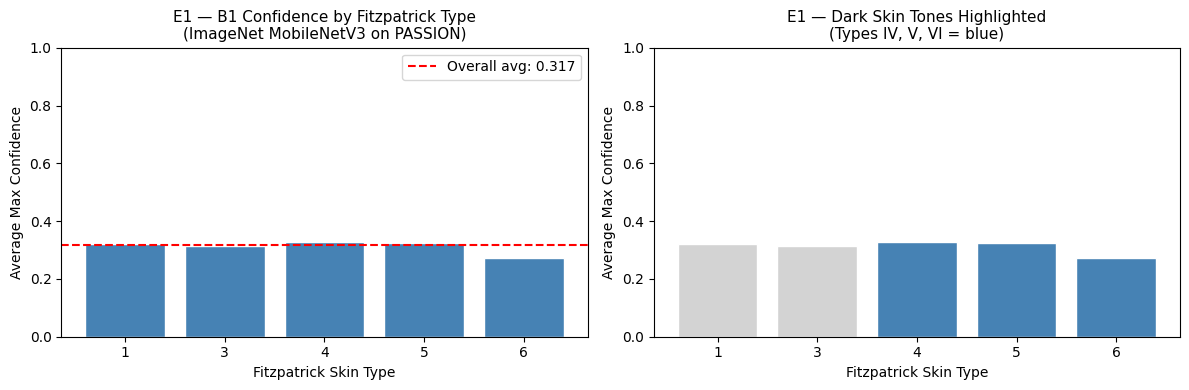

Plot saved as e1_results.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1 — confidence per Fitzpatrick type
fitz_types = list(fitz_confs_b1.keys())
fitz_vals  = list(fitz_confs_b1.values())

axes[0].bar([str(f) for f in fitz_types], fitz_vals, color='steelblue', edgecolor='white')
axes[0].axhline(y=overall_conf_b1, color='red', linestyle='--', label=f'Overall avg: {overall_conf_b1:.3f}')
axes[0].set_title('E1 — B1 Confidence by Fitzpatrick Type\n(ImageNet MobileNetV3 on PASSION)', fontsize=11)
axes[0].set_xlabel('Fitzpatrick Skin Type')
axes[0].set_ylabel('Average Max Confidence')
axes[0].set_ylim(0, 1)
axes[0].legend()

# Plot 2 — highlight types IV, V, VI (your target population)
colors_bar = ['lightgrey' if f < 4 else 'steelblue' for f in fitz_types]
axes[1].bar([str(f) for f in fitz_types], fitz_vals, color=colors_bar, edgecolor='white')
axes[1].set_title('E1 — Dark Skin Tones Highlighted\n(Types IV, V, VI = blue)', fontsize=11)
axes[1].set_xlabel('Fitzpatrick Skin Type')
axes[1].set_ylabel('Average Max Confidence')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('e1_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved as e1_results.png")

In [10]:
import json

e1_results = {
    "experiment":    "E1",
    "model":         "MobileNetV3-Small",
    "pretrained_on": "ImageNet (1000 classes)",
    "evaluated_on":  "PASSION (4 classes, Fitzpatrick III-VI)",
    "note":          "Accuracy not measurable — class spaces do not overlap. Confidence used as proxy metric.",
    "overall_avg_confidence":        round(overall_conf_b1, 4),
    "confidence_by_fitzpatrick_type": {
        str(k): round(v, 4) for k, v in fitz_confs_b1.items()
    }
}

with open('e1_results.json', 'w') as f:
    json.dump(e1_results, f, indent=2)

print("Results saved to e1_results.json")
print(json.dumps(e1_results, indent=2))

Results saved to e1_results.json
{
  "experiment": "E1",
  "model": "MobileNetV3-Small",
  "pretrained_on": "ImageNet (1000 classes)",
  "evaluated_on": "PASSION (4 classes, Fitzpatrick III-VI)",
  "note": "Accuracy not measurable \u2014 class spaces do not overlap. Confidence used as proxy metric.",
  "overall_avg_confidence": 0.3169,
  "confidence_by_fitzpatrick_type": {
    "1": 0.3216,
    "3": 0.3133,
    "4": 0.3277,
    "5": 0.3247,
    "6": 0.273
  }
}
